# Parameters Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
import pandas as pd
from scipy.stats import skewnorm
import seaborn as sns
import os

SEED = 20260415
RNG = np.random.default_rng(SEED)

NUM_STATES = 100
NUM_ACTIONS = 5
NUM_PATIENTS = 1000

SIGMA_LOW = 20
SIGMA_HIGH = 50

# K Annoatation Sources
NUM_SOURCES = 4
BASE_BIAS = 2
BASE_VAR = 6
BASE_COST = 10.0

# Multipliers for K sources
BIAS_MULTIPLIERS = np.array([1, 1, 2.25, 2.5])
VAR_MULTIPLIERS = np.array([1, 8, 0.5, 8])
COST_MULTIPLIERS = np.array([2, 0.5, 1, 0.1])

COSTS = BASE_COST * COST_MULTIPLIERS
BUDGET = NUM_PATIENTS * BASE_COST

print(f"Setup: S={NUM_STATES}, A={NUM_ACTIONS}, N={NUM_PATIENTS}, K={NUM_SOURCES}")
print(f"Costs: {COSTS}")


# Generate Initial Distribution d0
d0 = RNG.dirichlet(np.ones(NUM_STATES))

# Generate Behavior Policy pi_b
pi_b = RNG.dirichlet(np.ones(NUM_ACTIONS) * 0.2, size=NUM_STATES)
pi_b = np.clip(pi_b, 0.05, 1.0)
pi_b = pi_b / pi_b.sum(axis=1, keepdims=True)

# Generate Target Policy pi_e
FLIP_PROB = 0.1
pi_e = pi_b.copy()
for s in range(NUM_STATES):
    if RNG.random() < FLIP_PROB:
        perm = RNG.permutation(NUM_ACTIONS)
        pi_e[s] = pi_e[s][perm]

def generate_complex_reward(states, actions):
    r_stable = skewnorm.rvs(-2, loc=5, scale=6, size=(states, actions))
    r_critical = RNG.normal(loc=-2, scale=3, size=(states, actions))
    is_critical = RNG.random(size=(states, actions)) < 0.2
    return np.where(is_critical, r_critical, r_stable)

mu_r = generate_complex_reward(NUM_STATES, NUM_ACTIONS)
sigma_r_sq = RNG.uniform(low=SIGMA_LOW, high=SIGMA_HIGH, size=(NUM_STATES, NUM_ACTIONS))

# Generate Dataset
# Shape: (K, S, A)
eps_k = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
var_k_sa = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))

for k in range(NUM_SOURCES):
    # Bias
    loc_bias = BASE_BIAS * BIAS_MULTIPLIERS[k]
    eps_k[k] = RNG.normal(loc=loc_bias, scale=0.1 * (k+1), size=(NUM_STATES, NUM_ACTIONS))

    # Variance
    loc_var = BASE_VAR * VAR_MULTIPLIERS[k]
    var_k_sa[k] = np.abs(RNG.normal(loc=loc_var, scale=0.1, size=(NUM_STATES, NUM_ACTIONS)))

# Delta g_k = Var(g_k) - Var(r)
# Shape: (K, S, A)
delta_g_k = var_k_sa - sigma_r_sq[None, :, :]

# Generate Factual Data n_f(s, a)
state_counts = RNG.multinomial(NUM_PATIENTS, d0)
n_f = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=int)

for s in range(NUM_STATES):
    if state_counts[s] > 0:
        n_f[s] = RNG.multinomial(state_counts[s], pi_b[s])

# Calculate N_s (Total patients per state)
N_s = n_f.sum(axis=1)

print(f"Data Generated. Total Factual Samples: {n_f.sum()}")
print(f"Max samples in a single (s,a): {n_f.max()}")

Setup: S=100, A=5, N=1000, K=4
Costs: [20.  5. 10.  1.]
Data Generated. Total Factual Samples: 1000
Max samples in a single (s,a): 39


# Constant Terms

In [2]:
with np.errstate(divide='ignore', invalid='ignore'):
    w_sa = np.square(pi_e) / pi_b
    w_sa[pi_b == 0] = 0  # in case pi_b = 0

# --- Term 1: Var_{s~d0} (v(pi_e | s)) ---
v_pi_e_s = np.sum(pi_e * mu_r, axis=1) # Shape: (S,)
expected_v = np.dot(d0, v_pi_e_s)
term1_const = np.dot(d0, np.square(v_pi_e_s - expected_v))

# --- Term 2: E_{s~d0} [ E_{a~pi_b} [ rho^2 * sigma_r^2 ] ] ---
term2_inner = np.sum(w_sa * sigma_r_sq, axis=1)
term2_const = np.dot(d0, term2_inner)

print(f"Constant Term 1 (State Value Variance): {term1_const:.6f}")
print(f"Constant Term 2 (Intrinsic Reward Variance): {term2_const:.6f}")
print(f"Total Constant: {term1_const + term2_const:.6f}")

Constant Term 1 (State Value Variance): 7.041808
Constant Term 2 (Intrinsic Reward Variance): 51.824502
Total Constant: 58.866310


# Calculate Objective

In [3]:
def calc_objective(n_k):
    """
    n_k: Shape (K, NUM_STATES, NUM_ACTIONS)
    """
    # Sum annotations across sources: sum_k n_k(s,a)
    total_n_anno = np.sum(n_k, axis=0)
    N_sa = n_f + total_n_anno
    valid_mask = (N_sa > 0)

    # A = (sum_k n_k * eps_k) / N(s, a)
    # weighted_bias_sum shape: (S, A)
    weighted_bias_sum = np.sum(n_k * eps_k, axis=0)
    A_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_bias_sum, N_sa, out=A_term, where=valid_mask)

    # B = (sum_k n_k * delta_k) / N(s, a)^2
    weighted_delta_sum = np.sum(n_k * delta_g_k, axis=0)
    N_sq = np.square(N_sa)
    B_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_delta_sum, N_sq, out=B_term, where=valid_mask)

    # C = sigma_r^2 / N(s, a)
    C_term = np.zeros_like(N_sa, dtype=float)
    np.divide(sigma_r_sq, N_sa, out=C_term, where=valid_mask)

    # Part 1: sum_a [ (pi_e^2 / pi_b) * A^2 ]
    part1_sa = w_sa * np.square(A_term)
    part1_s = np.sum(part1_sa, axis=1)

    # Part 2: - ( sum_a [ pi_e * A ] )^2
    part2_inner = np.sum(pi_e * A_term, axis=1)
    part2_s = np.square(part2_inner)

    # Part 3: sum_a [ (pi_e^2 / pi_b - pi_e^2) * (C + B) ]
    coef = w_sa - np.square(pi_e)
    part3_sa = coef * (C_term + B_term)
    part3_s = np.sum(part3_sa, axis=1)

    # J_3 = sum_s d0(s) * [ Part1 - Part2 + Part3 ]
    term3_s = part1_s - part2_s + part3_s
    term3_total = np.dot(d0, term3_s)

    total_J = term1_const + term2_const + term3_total

    return total_J

# Test
n_k_zero = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS), dtype=int)
J_0 = calc_objective(n_k_zero)
print(f"Objective with no annotations: {J_0:.6f}")

n_k_rand = RNG.poisson(lam=1.0, size=(NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
J_rand = calc_objective(n_k_rand)
print(f"Objective with random annotations: {J_rand:.6f}")

Objective with no annotations: 71.588589
Objective with random annotations: 68.609232


In [4]:
def allocate_budget_randomly(n_f, budget, costs, source_idx=None):
    """
    Allocates budget randomly.
    If source_idx is provided, allocates only to that source.
    Otherwise, picks a random source for each patient.
    """
    n_alloc = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS), dtype=int)

    # Determine cost per annotation
    # If random source, we approximate cost or pick source first then check budget
    # For simplicity, we list all patients and iterate

    patient_list = []
    rows, cols = n_f.nonzero()
    for s, a in zip(rows, cols):
        count = n_f[s, a]
        patient_list.extend([(s, a)] * count)

    RNG.shuffle(patient_list)

    current_spend = 0.0

    for s, a_factual in patient_list:
        possible_actions = np.arange(NUM_ACTIONS)
        possible_counterfactuals = np.delete(possible_actions, a_factual)
        a_target = RNG.choice(possible_counterfactuals)

        # Pick source
        if source_idx is not None:
            k = source_idx
        else:
            k = RNG.integers(0, NUM_SOURCES)

        cost = costs[k]

        if current_spend + cost <= budget:
            n_alloc[k, s, a_target] += 1
            current_spend += cost
        else:
            # Budget exhausted
            break

    return n_alloc

# Test
print(f"\n--- All Budget to Source 0 (Cost {COSTS[0]}) ---")
n_k_s0 = allocate_budget_randomly(n_f, BUDGET, COSTS, source_idx=0)
J_s0 = calc_objective(n_k_s0)
print(f"Objective: {J_s0:.4f}, Count: {n_k_s0.sum()}")

print(f"\n--- All Budget to Source 1 (Cost {COSTS[1]}) ---")
n_k_s1 = allocate_budget_randomly(n_f, BUDGET, COSTS, source_idx=1)
J_s1 = calc_objective(n_k_s1)
print(f"Objective: {J_s1:.4f}, Count: {n_k_s1.sum()}")


--- All Budget to Source 0 (Cost 20.0) ---
Objective: 66.2364, Count: 500

--- All Budget to Source 1 (Cost 5.0) ---
Objective: 74.3088, Count: 1000


# Test the influence of different parts

In [5]:
def get_variance_components(n_f, n_k,
                            eps_k, delta_g_k,
                            sigma_r_sq,
                            pi_e, pi_b, d0,
                            term1_const, term2_const):

    with np.errstate(divide='ignore', invalid='ignore'):
        w_sa = np.square(pi_e) / pi_b
        w_sa[pi_b == 0] = 0

    total_n_anno = np.sum(n_k, axis=0)
    N_sa = n_f + total_n_anno
    valid_mask = (N_sa > 0)

    # --- Term A ---
    weighted_bias_sum = np.sum(n_k * eps_k, axis=0)
    A_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_bias_sum, N_sa, out=A_term, where=valid_mask)

    # --- Term B ---
    weighted_delta_sum = np.sum(n_k * delta_g_k, axis=0)
    N_sq = np.square(N_sa)
    B_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_delta_sum, N_sq, out=B_term, where=valid_mask)

    # --- Term C ---
    C_term = np.zeros_like(N_sa, dtype=float)
    np.divide(sigma_r_sq, N_sa, out=C_term, where=valid_mask)

    # --- Part 1 ---
    part1_sa = w_sa * np.square(A_term)
    part1_s = np.sum(part1_sa, axis=1)
    part1_total = np.dot(d0, part1_s)

    # --- Part 2 ---
    part2_inner = np.sum(pi_e * A_term, axis=1)
    part2_s = np.square(part2_inner)
    part2_total = np.dot(d0, part2_s)

    # --- Part 3 ---
    coef = w_sa - np.square(pi_e)
    part3_sa = coef * (C_term + B_term)
    part3_s = np.sum(part3_sa, axis=1)
    part3_total = np.dot(d0, part3_s)

    total_variable_var = part1_total - part2_total + part3_total
    total_J = term1_const + term2_const + total_variable_var

    return {
        "Const_Term1": float(term1_const),
        "Const_Term2": float(term2_const),
        "Part1": float(part1_total),
        "Part2": float(part2_total),
        "Part3": float(part3_total),
        "Total_Variance": float(total_J)
    }

In [6]:
def generate_environment(seed):
    rng = np.random.default_rng(seed)

    # Policies & Distribution
    d0 = rng.dirichlet(np.ones(NUM_STATES))

    pi_b = rng.dirichlet(np.ones(NUM_ACTIONS) * 0.2, size=NUM_STATES)
    pi_b = np.clip(pi_b, 0.05, 1.0)
    pi_b = pi_b / pi_b.sum(axis=1, keepdims=True)

    pi_e = pi_b.copy()
    for s in range(NUM_STATES):
        if rng.random() < FLIP_PROB:
            perm = rng.permutation(NUM_ACTIONS)
            pi_e[s] = pi_e[s][perm]

    # Reward & Noise
    r_stable = skewnorm.rvs(-2, loc=5, scale=6, size=(NUM_STATES, NUM_ACTIONS), random_state=rng)
    r_critical = rng.normal(loc=-2, scale=3, size=(NUM_STATES, NUM_ACTIONS))
    is_critical = rng.random(size=(NUM_STATES, NUM_ACTIONS)) < 0.1
    mu_r = np.where(is_critical, r_critical, r_stable)

    sigma_r_sq = rng.uniform(low=SIGMA_LOW, high=SIGMA_HIGH, size=(NUM_STATES, NUM_ACTIONS))

    # K Sources Data
    eps_k = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
    var_k_sa = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))

    for k in range(NUM_SOURCES):
        loc_bias = BASE_BIAS * BIAS_MULTIPLIERS[k]
        eps_k[k] = rng.normal(loc=loc_bias, scale=0.1 * (k+1), size=(NUM_STATES, NUM_ACTIONS))
        loc_var = BASE_VAR * VAR_MULTIPLIERS[k]
        var_k_sa[k] = np.abs(rng.normal(loc=loc_var, scale=0.1, size=(NUM_STATES, NUM_ACTIONS)))

    delta_g_k = var_k_sa - sigma_r_sq[None, :, :]

    # Factual Data
    state_counts = rng.multinomial(NUM_PATIENTS, d0)
    n_f = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=int)
    for s in range(NUM_STATES):
        if state_counts[s] > 0:
            n_f[s] = rng.multinomial(state_counts[s], pi_b[s])

    # Constant Terms
    v_pi_e_s = np.sum(pi_e * mu_r, axis=1)
    expected_v = np.dot(d0, v_pi_e_s)
    term1_const = np.dot(d0, np.square(v_pi_e_s - expected_v))

    with np.errstate(divide='ignore', invalid='ignore'):
        w_sa = np.square(pi_e) / pi_b
        w_sa[pi_b == 0] = 0
    term2_inner = np.sum(w_sa * sigma_r_sq, axis=1)
    term2_const = np.dot(d0, term2_inner)

    return {
        "n_f": n_f, "pi_e": pi_e, "pi_b": pi_b, "d0": d0,
        "eps_k": eps_k, "delta_g_k": delta_g_k,
        "sigma_r_sq": sigma_r_sq,
        "term1_const": term1_const, "term2_const": term2_const
    }

Simulation Complete. Total records: 1600


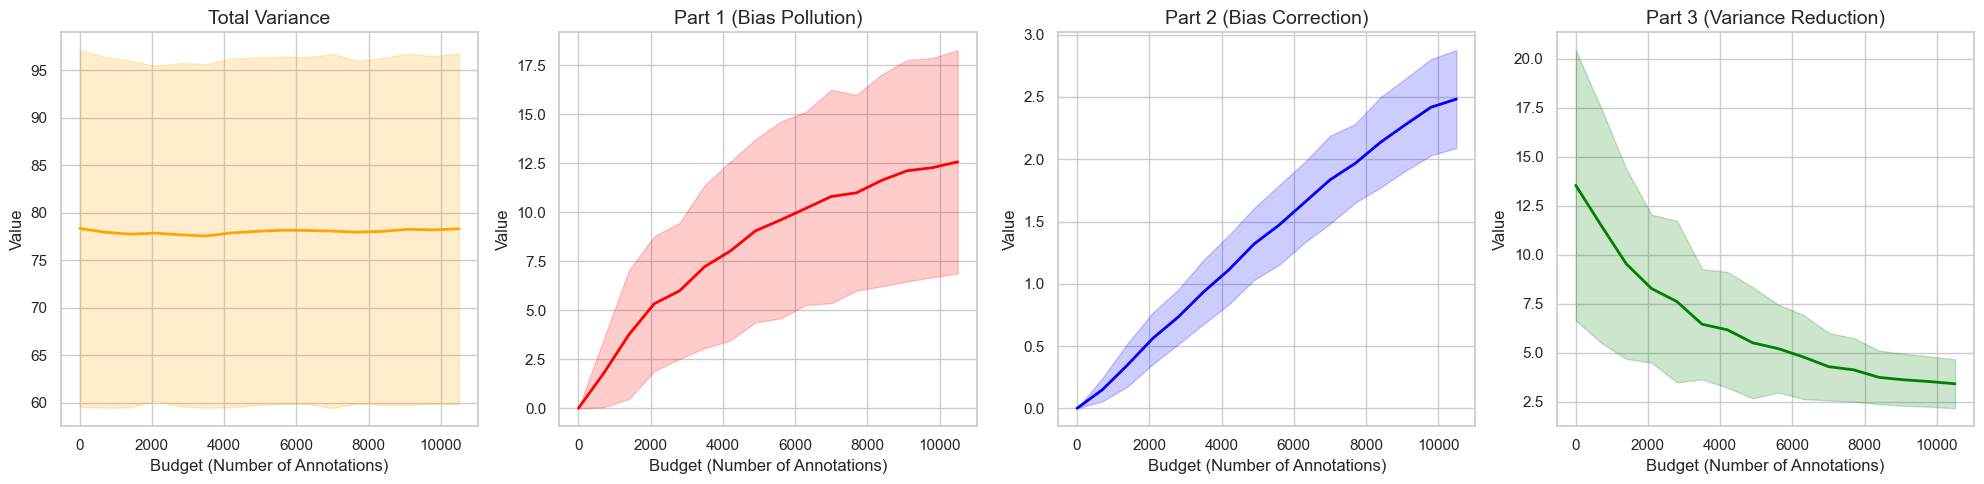

,Const_Term1,Const_Term2,Part1,Part2,Part3,Total_Variance
Budget,,,,,,
1,8.341492,56.482668,0.000000,0.000000,13.535806,78.359965
700,8.341492,56.482668,1.782780,0.148591,11.503080,77.961429
1400,8.341492,56.482668,3.756460,0.348748,9.527117,77.758989
2100,8.341492,56.482668,5.333443,0.562116,8.268337,77.863824
2800,8.341492,56.482668,5.988150,0.732863,7.607625,77.687071
3500,8.341492,56.482668,7.228205,0.933640,6.449248,77.567972
4200,8.341492,56.482668,8.011361,1.111386,6.164030,77.888166
4900,8.341492,56.482668,9.047509,1.319097,5.502055,78.054627
5600,8.341492,56.482668,9.606931,1.473203,5.209703,78.167589


In [7]:
# Roll 100 times
NUM_ROLLS = 100
source_idx = 2
budget_steps = np.linspace(1, BASE_COST * COST_MULTIPLIERS[source_idx] * NUM_PATIENTS * 1.05, 16, dtype=int)

all_results = []

for roll in range(NUM_ROLLS):
    env = generate_environment(SEED + roll)

    for budget in budget_steps:
        if budget == 0:
            n_k_alloc = np.zeros_like(env['eps_k'], dtype=int)
        else:
            # Allocate all budget to one source
            n_k_alloc = allocate_budget_randomly(env['n_f'], budget, COSTS, source_idx)

        comps = get_variance_components(
            env['n_f'], n_k_alloc,
            env['eps_k'], env['delta_g_k'],
            env['sigma_r_sq'],
            env['pi_e'], env['pi_b'], env['d0'],
            env['term1_const'], env['term2_const']
        )

        res = comps.copy()
        res['Budget'] = budget
        res['Roll'] = roll
        all_results.append(res)

df_results = pd.DataFrame(all_results)
print(f"Simulation Complete. Total records: {len(df_results)}")

# Plot result
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [
    ("Total_Variance", "Total Variance", "orange"),
    ("Part1", "Part 1 (Bias Pollution)", "red"),
    ("Part2", "Part 2 (Bias Correction)", "blue"),
    ("Part3", "Part 3 (Variance Reduction)", "green")
]

for i, (metric, title, color) in enumerate(metrics):

    sns.lineplot(
        data=df_results,
        x="Budget",
        y=metric,
        ax=axes[i],
        color=color,
        errorbar='sd',
        linewidth=2
    )

    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel("Budget (Number of Annotations)", fontsize=12)
    axes[i].set_ylabel("Value", fontsize=12)

    # axes[i].set_ylim(bottom=0)

plt.tight_layout()
#plt.savefig("variance_decomposition_4.png")
plt.show()

df_summary = df_results.groupby("Budget").mean().drop(columns=["Roll"])
display(df_summary)

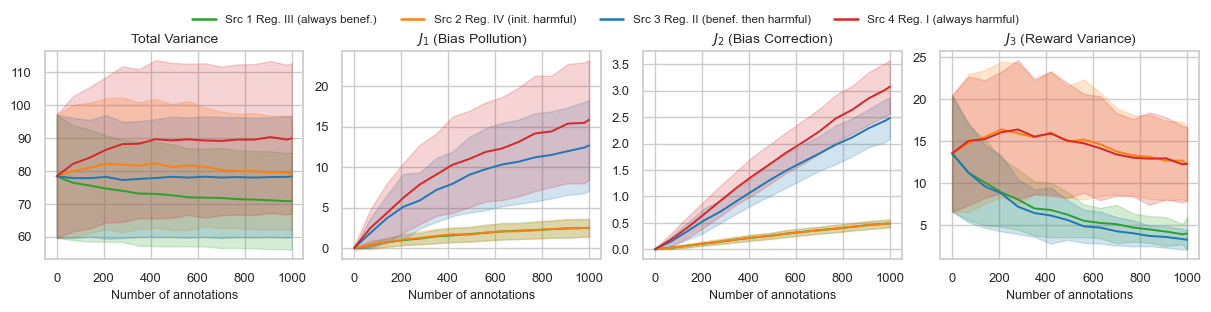

In [8]:
NUM_ROLLS = 100
N_STEPS   = 16

all_results = []
for source_idx in range(NUM_SOURCES):
    # Budget just enough to saturate "annotate-once" cap (+5% margin)
    max_budget   = COSTS[source_idx] * NUM_PATIENTS * 1.05
    budget_steps = np.linspace(1, max_budget, N_STEPS, dtype=int)

    for roll in range(NUM_ROLLS):
        env = generate_environment(SEED + roll)
        for budget in budget_steps:
            n_k_alloc = allocate_budget_randomly(
                env['n_f'], budget, COSTS, source_idx)
            comps = get_variance_components(
                env['n_f'], n_k_alloc,
                env['eps_k'], env['delta_g_k'], env['sigma_r_sq'],
                env['pi_e'], env['pi_b'], env['d0'],
                env['term1_const'], env['term2_const'])
            comps['Num_Annotations'] = int(n_k_alloc.sum())
            comps['Source'] = source_idx + 1
            comps['Roll']   = roll
            all_results.append(comps)

df_all = pd.DataFrame(all_results)

sns.set_theme(style='whitegrid', font_scale=0.85)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharex=False,
                         constrained_layout=True)

metrics = [
    ("Total_Variance", "Total Variance"),
    ("Part1",          r"$J_1$ (Bias Pollution)"),
    ("Part2",          r"$J_2$ (Bias Correction)"),
    ("Part3",          r"$J_3$ (Reward Variance)"),
]
regime_info = {
    1: ("Src 1 Reg. III (always benef.)",       "tab:green"),
    2: ("Src 2 Reg. IV (init. harmful)",        "tab:orange"),
    3: ("Src 3 Reg. II (benef. then harmful)",  "tab:blue"),
    4: ("Src 4 Reg. I (always harmful)",        "tab:red"),
}

handles, labels = [], []
for i, (metric, title) in enumerate(metrics):
    for k, (lbl, color) in regime_info.items():
        dfk = df_all[df_all['Source'] == k]
        ln = sns.lineplot(
            data=dfk, x='Num_Annotations', y=metric,
            ax=axes[i], color=color, errorbar='sd', linewidth=1.4,
            label=lbl if i == 0 else None, legend=False)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Number of annotations", fontsize=9)
    axes[i].set_ylabel("")

# Collect handles from axes[0] (lines plotted there) and move to figure top
handles = [plt.Line2D([0], [0], color=c, lw=1.8) for _, c in regime_info.values()]
labels  = [lbl for lbl, _ in regime_info.values()]
fig.legend(handles, labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=4, frameon=False, fontsize=8.5)

plt.savefig("four_regimes_combined.png", bbox_inches='tight')
plt.show()

# Optimization

In [9]:
def get_mm_coefficients(n_k_iter):
    """
    n_k_iter: Shape (K, S, A)
    """
    # Calculate N(s, a) based on current iteration k
    total_n = np.sum(n_k_iter, axis=0)
    N_sa_k = n_f + total_n

    # Avoid division by zero
    valid_mask = (N_sa_k > 0)

    # Calculate A_sa(n^(k)) = (sum_k n_k * eps_k) / N_sa
    weighted_bias = np.sum(n_k_iter * eps_k, axis=0)
    A_term_k = np.zeros_like(N_sa_k, dtype=float)
    np.divide(weighted_bias, N_sa_k, out=A_term_k, where=valid_mask)

    # Calculate B_s(n^(k)) = sum_a pi_e(a|s) * A_sa(n^(k))
    B_s_k = np.sum(pi_e * A_term_k, axis=1) # Shape (S,)

    # Omega 1: w1(s, a) = d0(s) * (pi_e(a|s)^2 / pi_b(a|s))
    omega1 = d0[:, None] * w_sa

    # Omega 2: w2(s, a) = -2 * d0(s) * B_s(n^(k)) * pi_e(a|s)
    omega2 = -2 * d0[:, None] * B_s_k[:, None] * pi_e

    # Omega 3: w3(s, a) = d0(s) * (pi_e^2/pi_b - pi_e^2)
    coef = w_sa - np.square(pi_e)
    omega3 = d0[:, None] * coef

    return omega1, omega2, omega3

In [10]:
class BudgetOptimizer:
    def __init__(self, n_f, N_s, budget, costs):
        self.n_f = n_f
        self.N_s = N_s
        self.budget = budget
        self.costs = costs # Array of shape (K,)
        self.num_sources = len(costs)
        self.num_states, self.num_actions = n_f.shape

    def _local_cost(self, s, a, n_vec, omega1, omega2, omega3, lam):
        """
        Calculate psi_{s,a}(n_vec) + lambda * cost
        """
        m = np.sum(n_vec)
        N_val = self.n_f[s, a] + m

        if N_val == 0:
            return np.inf

        # Term A: (sum n_k * eps_k) / N
        eps_val = eps_k[:, s, a]
        term_A = np.dot(n_vec, eps_val) / N_val

        # Term B+C: sigma^2/N + (sum n_k * delta_k) / N^2
        delta_val = delta_g_k[:, s, a]
        term_BC = (sigma_r_sq[s, a] / N_val) + \
                  (np.dot(n_vec, delta_val)) / (N_val**2)

        # Surrogate Objective
        obj_val = omega1[s, a] * (term_A**2) + \
                  omega2[s, a] * term_A + \
                  omega3[s, a] * term_BC

        # Lagrangian Cost
        lag_cost = lam * np.dot(self.costs, n_vec)

        return obj_val + lag_cost

    def _solve_step1_pairwise_exchange(self, s, a, m, omega1, omega2, omega3, lam):
        # Init: Allocate all m to cheapest source
        cheapest_k = np.argmin(self.costs)
        n_vec = np.zeros(self.num_sources, dtype=int)
        n_vec[cheapest_k] = m

        current_cost = self._local_cost(s, a, n_vec, omega1, omega2, omega3, lam)

        improved = True
        while improved:
            improved = False
            best_swap = None
            best_swap_gain = 0.0

            # Try moving 1 unit from u to v
            for u in range(self.num_sources):
                if n_vec[u] > 0:
                    for v in range(self.num_sources):
                        if u == v: continue

                        # Tentative swap
                        n_vec[u] -= 1
                        n_vec[v] += 1

                        new_cost = self._local_cost(s, a, n_vec, omega1, omega2, omega3, lam)
                        gain = current_cost - new_cost

                        if gain > best_swap_gain + 1e-9:
                            best_swap_gain = gain
                            best_swap = (u, v)

                        # Revert
                        n_vec[v] -= 1
                        n_vec[u] += 1

            if best_swap:
                u, v = best_swap
                n_vec[u] -= 1
                n_vec[v] += 1
                current_cost -= best_swap_gain
                improved = True

        return current_cost, n_vec.copy()

    def _solve_state_dp(self, s, omega1, omega2, omega3, lam):
        capacity = self.N_s[s]
        dp = np.full(capacity + 1, np.inf)
        dp[0] = 0.0

        parent_m = np.full((self.num_actions, capacity + 1), -1, dtype=int)

        H_costs = []
        H_vecs = []

        for a in range(self.num_actions):
            max_m = capacity - self.n_f[s, a]
            costs_a = []
            vecs_a = []
            for m in range(max_m + 1):
                c, vec = self._solve_step1_pairwise_exchange(s, a, m, omega1, omega2, omega3, lam)
                costs_a.append(c)
                vecs_a.append(vec)
            H_costs.append(costs_a)
            H_vecs.append(vecs_a)

        for a in range(self.num_actions):
            new_dp = np.full(capacity + 1, np.inf)
            max_m_a = len(H_costs[a]) - 1

            for w in range(capacity + 1):
                if dp[w] == np.inf: continue

                for m in range(max_m_a + 1):
                    new_w = w + m
                    if new_w <= capacity:
                        cost = dp[w] + H_costs[a][m]
                        if cost < new_dp[new_w]:
                            new_dp[new_w] = cost
                            parent_m[a][new_w] = m
            dp = new_dp

        best_w = np.argmin(dp)
        if dp[best_w] == np.inf:
            return 0.0, np.zeros((self.num_sources, self.num_actions), dtype=int)

        n_k_s = np.zeros((self.num_sources, self.num_actions), dtype=int)
        curr_w = best_w
        for a in range(self.num_actions - 1, -1, -1):
            m = parent_m[a][curr_w]
            vec = H_vecs[a][m]
            n_k_s[:, a] = vec
            curr_w -= m

        return dp[best_w], n_k_s

    def solve_subproblem(self, omega1, omega2, omega3, lam):
        n_k_new = np.zeros((self.num_sources, self.num_states, self.num_actions), dtype=int)

        for s in range(self.num_states):
            if self.N_s[s] == 0: continue
            _, n_k_s = self._solve_state_dp(s, omega1, omega2, omega3, lam)
            n_k_new[:, s, :] = n_k_s

        usage = 0.0
        for k in range(self.num_sources):
            usage += np.sum(n_k_new[k]) * self.costs[k]

        return n_k_new, usage

    def optimize(self, max_mm_iter=10, tol=1e-4):
        # Initialize with zeros
        n_k = np.zeros((self.num_sources, self.num_states, self.num_actions), dtype=int)
        history = []

        header = f"{'Iter':<5} | {'Objective':<12} | {'Cost':<10} | {'Total N':<10}"
        for k in range(self.num_sources):
            header += f" | {'n_' + str(k):<8}"
        header += f" | {'Lambda':<10}"

        print(header)
        print("-" * len(header))

        # Iteration -1:No Annotations
        baseline_obj = calc_objective(n_k)
        baseline_counts = np.zeros(self.num_sources, dtype=int)

        # Print Baseline Row
        row_str = f"{'-1':<5} | {baseline_obj:<12.6f} | {0.0:<10.1f} | {0:<10}"
        for count in baseline_counts:
            row_str += f" | {count:<8}"
        row_str += f" | {0.0:<10.4f}"
        print(row_str)

        # Record Baseline History
        hist_entry = {
            'iter': -1,
            'obj': baseline_obj,
            'usage': 0.0,
            'total_n': 0,
            'lambda': 0.0
        }
        for idx, count in enumerate(baseline_counts):
            hist_entry[f'n_{idx}'] = count
        history.append(hist_entry)


        # --- MM Loop ---
        for k in range(max_mm_iter):
            omega1, omega2, omega3 = get_mm_coefficients(n_k)

            # Bisection Search for Lambda
            lam_low = 0.0
            lam_high = 1.0

            while True:
                _, usage = self.solve_subproblem(omega1, omega2, omega3, lam_high)
                if usage <= self.budget:
                    break
                lam_low = lam_high
                lam_high *= 2
                if lam_high > 1e6: break

            best_lam = lam_high
            n_k_next = n_k

            for _ in range(20):
                lam_mid = (lam_low + lam_high) / 2
                n_cand, usage = self.solve_subproblem(omega1, omega2, omega3, lam_mid)

                if usage > self.budget:
                    lam_low = lam_mid
                else:
                    best_lam = lam_mid
                    lam_high = lam_mid
                    n_k_next = n_cand

            # Final solve
            n_k_next, final_usage = self.solve_subproblem(omega1, omega2, omega3, best_lam)

            current_obj = calc_objective(n_k_next)

            # Calculate counts per source
            counts_per_source = np.sum(n_k_next, axis=(1, 2)) # Sum over S and A
            total_n = np.sum(counts_per_source)

            # Print Row
            row_str = f"{k:<5} | {current_obj:<12.6f} | {final_usage:<10.1f} | {total_n:<10}"
            for count in counts_per_source:
                row_str += f" | {count:<8}"
            row_str += f" | {best_lam:<10.4f}"
            print(row_str)

            # Record History
            hist_entry = {
                'iter': k,
                'obj': current_obj,
                'usage': final_usage,
                'total_n': total_n,
                'lambda': best_lam
            }
            for idx, count in enumerate(counts_per_source):
                hist_entry[f'n_{idx}'] = count
            history.append(hist_entry)

            if k > 0 and np.abs(history[-1]['obj'] - history[-2]['obj']) < tol:
                print("Converged.")
                break

            n_k = n_k_next

        return n_k, pd.DataFrame(history)

In [11]:
# Initialize Optimizer
optimizer = BudgetOptimizer(n_f, N_s, BUDGET, COSTS)

# Run Optimization
print("Starting Optimization...")
n_k_opt, history_df = optimizer.optimize(max_mm_iter=15)

# Calculate Baseline (Verification)
baseline_obj = history_df.iloc[0]['obj'] # Iter -1 is now the first row
final_obj = history_df.iloc[-1]['obj']

print(f"\nBaseline Variance: {baseline_obj:.6f}")
print(f"Optimized Variance: {final_obj:.6f}")
print(f"Reduction: {(baseline_obj - final_obj)/baseline_obj * 100:.2f}%")

Starting Optimization...
Iter  | Objective    | Cost       | Total N    | n_0      | n_1      | n_2      | n_3      | Lambda    
-------------------------------------------------------------------------------------------------------
-1    | 71.588589    | 0.0        | 0          | 0        | 0        | 0        | 0        | 0.0000    
0     | 63.113352    | 9986.0     | 620        | 452      | 145      | 22       | 1        | 0.0001    
1     | 62.868380    | 9968.0     | 713        | 397      | 176      | 112      | 28       | 0.0001    
2     | 62.733283    | 9971.0     | 773        | 352      | 164      | 206      | 51       | 0.0001    
3     | 62.679660    | 9895.0     | 797        | 326      | 141      | 260      | 70       | 0.0001    
4     | 62.642720    | 9956.0     | 844        | 309      | 160      | 289      | 86       | 0.0001    
5     | 62.623276    | 9972.0     | 851        | 302      | 137      | 315      | 97       | 0.0001    
6     | 62.610175    | 9997.0     | 842

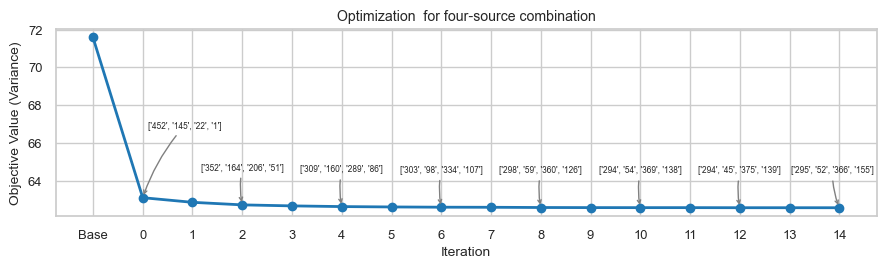

In [27]:
plt.figure(figsize=(9, 2.8))
plot_iters = history_df['iter'].tolist()
plot_objs = history_df['obj'].tolist()


plt.plot(plot_iters, plot_objs, marker='o', linestyle='-', color='tab:blue',
         linewidth=2, label='Total Variance', zorder=1)


n_cols = [col for col in history_df.columns if col.startswith('n_')]


total_points = len(plot_iters)
indices_to_label = [1, 3, 5, 7, 9, 11, 13, 15]


indices_to_label = sorted(list(set(indices_to_label)))

for idx in indices_to_label:
    it = plot_iters[idx]
    obj = plot_objs[idx]

    n_values = history_df.iloc[idx][n_cols].tolist()

    n_str_list = [str(int(v)) if v == int(v) else f"{v:.1f}" for v in n_values]

    n_display = f"{n_str_list}"

    if idx == indices_to_label[-1]:
      plt.annotate(n_display,
                 xy=(it, obj),
                 xytext=(-5, 25),
                 textcoords='offset points',
                 ha='center',
                 fontsize=6,
                 arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))
    elif idx == indices_to_label[0]:
        plt.annotate(n_display,
                 xy=(it, obj),
                 xytext=(30, 50),
                 textcoords='offset points',
                 ha='center',
                 fontsize=6,
                 arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))
    else:
      plt.annotate(n_display,
                  xy=(it, obj),
                  xytext=(0, 25),
                  textcoords='offset points',
                  ha='center',
                  fontsize=6,
                  arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))


plt.xlabel('Iteration', fontsize=10)
plt.ylabel('Objective Value (Variance)', fontsize=10)
plt.title('Optimization  for four-source combination')

plt.xticks(plot_iters, ['Base' if i == -1 else str(i) for i in plot_iters])
plt.grid(True)

plt.tight_layout()
plt.savefig("optimization_syn.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
from itertools import combinations

# ----------------------------------------------------------------------
# Optimizer restricted to a subset of sources
# ----------------------------------------------------------------------
class BudgetOptimizerSubset(BudgetOptimizer):
    def __init__(self, n_f, N_s, budget, costs, active_sources):
        super().__init__(n_f, N_s, budget, costs)
        self.active_sources = list(active_sources)

    def _solve_step1_pairwise_exchange(self, s, a, m,
                                       omega1, omega2, omega3, lam):
        active = self.active_sources
        cheapest_k = active[np.argmin(self.costs[active])]
        n_vec = np.zeros(self.num_sources, dtype=int)
        n_vec[cheapest_k] = m
        current_cost = self._local_cost(s, a, n_vec,
                                        omega1, omega2, omega3, lam)

        improved = True
        while improved:
            improved = False
            best_swap, best_gain = None, 0.0
            for u in active:
                if n_vec[u] == 0: continue
                for v in active:
                    if u == v: continue
                    n_vec[u] -= 1; n_vec[v] += 1
                    new_cost = self._local_cost(s, a, n_vec,
                                                omega1, omega2, omega3, lam)
                    gain = current_cost - new_cost
                    if gain > best_gain + 1e-9:
                        best_gain, best_swap = gain, (u, v)
                    n_vec[v] -= 1; n_vec[u] += 1
            if best_swap:
                u, v = best_swap
                n_vec[u] -= 1; n_vec[v] += 1
                current_cost -= best_gain
                improved = True
        return current_cost, n_vec.copy()


# ----------------------------------------------------------------------
# Enumerate all 15 non-empty subsets of {1,2,3,4}
# ----------------------------------------------------------------------
all_ids = list(range(NUM_SOURCES))
combos  = [c for r in range(1, NUM_SOURCES + 1)
             for c in combinations(all_ids, r)]

baseline_no_anno = calc_objective(
    np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS), dtype=int))

results = []
for combo in combos:
    label = '{' + ','.join(str(i + 1) for i in combo) + '}'
    if len(combo) == 1:
        # single-source baseline: random allocation of full budget
        src = combo[0]
        n_k_alloc = allocate_budget_randomly(n_f, BUDGET, COSTS, source_idx=src)
        obj = calc_objective(n_k_alloc)
    else:
        print(f"Optimising combo {label} ...")
        opt = BudgetOptimizerSubset(n_f, N_s, BUDGET, COSTS, list(combo))
        _, hist = opt.optimize(max_mm_iter=10)
        obj = hist.iloc[-1]['obj']
    results.append({'label': label,
                    'num_sources': len(combo),
                    'objective': obj})

df_combo = (pd.DataFrame(results)
              .sort_values(['num_sources', 'objective'])
              .reset_index(drop=True))
print(df_combo)

Optimising combo {1,2} ...
Iter  | Objective    | Cost       | Total N    | n_0      | n_1      | n_2      | n_3      | Lambda    
-------------------------------------------------------------------------------------------------------
-1    | 71.588589    | 0.0        | 0          | 0        | 0        | 0        | 0        | 0.0000    
0     | 63.143067    | 9950.0     | 613        | 459      | 154      | 0        | 0        | 0.0001    
1     | 63.046949    | 9975.0     | 732        | 421      | 311      | 0        | 0        | 0.0001    
2     | 63.039065    | 9900.0     | 780        | 400      | 380      | 0        | 0        | 0.0001    
3     | 63.028287    | 9945.0     | 801        | 396      | 405      | 0        | 0        | 0.0001    
4     | 63.020487    | 10000.0    | 812        | 396      | 416      | 0        | 0        | 0.0001    
5     | 63.028737    | 9915.0     | 825        | 386      | 439      | 0        | 0        | 0.0001    
6     | 63.024860    | 9945.0     | 8

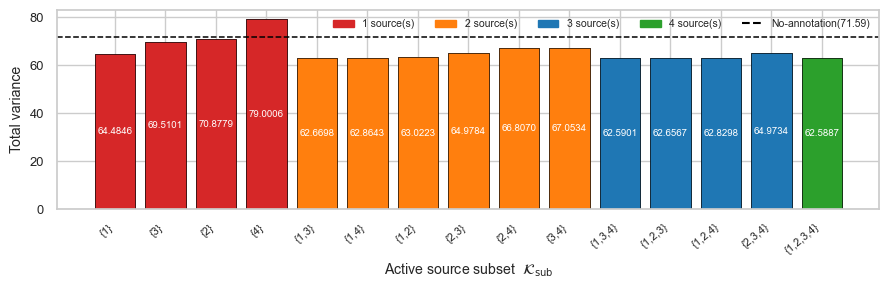

In [14]:
sns.set_theme(style='whitegrid', font_scale=0.85)
fig, ax = plt.subplots(figsize=(9, 3.0))
colour_by_size = {1: '#d62728', 2: '#ff7f0e', 3: '#1f77b4', 4: '#2ca02c'}
colours = [colour_by_size[n] for n in df_combo['num_sources']]

x = np.arange(len(df_combo))
bars = ax.bar(x, df_combo['objective'], color=colours,edgecolor='black', linewidth=0.4)


ax.bar(x, df_combo['objective'], color=colours,
       edgecolor='black', linewidth=0.4)
ax.bar_label(bars, fmt='%.4f', label_type='center', color='white', fontsize=7)
ax.axhline(baseline_no_anno, color='black', linestyle='--', linewidth=1.1)

ax.set_xticks(x)
ax.set_xticklabels(df_combo['label'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Total variance')
ax.set_xlabel('Active source subset  $\\mathcal{K}_{\\mathrm{sub}}$')

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colour_by_size[k],
                                label=f'{k} source(s)') for k in [1, 2, 3, 4]]
legend_handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                                 label=f'No-annotation({baseline_no_anno:.2f})'))

ax.legend(handles=legend_handles, loc='upper right',
          fontsize=7.5, ncol=5, frameon=False)

plt.tight_layout()
plt.savefig("source_combinations.png", dpi=150, bbox_inches='tight')
plt.show()

# Real LLMs Annotations in ASSIT dataset

* **Gemini Flash 2.5**
    * Price per 1M tokens: `$0.30` (Input), `$2.50` (Output)
    * Prompt tokens: `4,776,600`, Completion tokens: `711,597`
    * Total Estimated Cost for 20 replications: **`$1.14`**

* **GPT-4o-mini**
    * Price per 1M tokens: `$0.15` (Input), `$0.60` (Output)
    * Prompt tokens: `4,446,160`, Completion tokens: `411,973`
    * Total Estimated Cost for 20 replications: **`$0.4763`**

* **GPT-o3-mini**
    * Price per 1M tokens: `$1.1` (Input), `$4.4` (Output)
    * Prompt tokens: `4,446,160`, Completion tokens: `7,358,757`
    * Total Estimated Cost for 20 replications: **`$37.26`**

* **Claude-haiku-4.5**
    * Price per 1M tokens: `$1` (Input), `$5` (Output)
    * Prompt tokens: `6,047,398`, Completion tokens: `818,318`
    * Total Estimated Cost 20 replications: **`$8.11`**

## Load Data

In [15]:
# Gemini
LLM_DATA_PATH = "ASSIST_annotations_gemini.npz"
LLM_output = np.load(LLM_DATA_PATH)
ann_mu_gemini = LLM_output['ann_mu']
var_k_sa_gemini = LLM_output['ann_var']

# Claude
CLAUDE_DATA_PATH = "ASSIST_annotations_claudehaiku.npz"
claude_output = np.load(CLAUDE_DATA_PATH)
ann_mu_claude = claude_output['ann_mu']
var_k_sa_claude = claude_output['ann_var']

# GPT-4o-mini
GPT4o_DATA_PATH = "ASSIST_annotations_gpt4omini.npz"
gpt4o_output = np.load(GPT4o_DATA_PATH)
ann_mu_gpt4o = gpt4o_output['ann_mu']
var_k_sa_gpt4o = gpt4o_output['ann_var']

# GPT-o3-mini
GPTo3_DATA_PATH = "ASSIST_annotations_gpto3mini.npz"
gpto3_output = np.load(GPTo3_DATA_PATH)
ann_mu_gpto3 = gpto3_output['ann_mu']
var_k_sa_gpto3 = gpto3_output['ann_var']


In [16]:
ann_mu_claude.shape

(100, 10)

## Build Environment

In [17]:
SEED = 20260305
data_path = "ASSIST_params_irt_time.npz"
data = np.load(data_path)

NUM_SOURCES_BKT = 3
NUM_STATES_BKT = 100
NUM_ACTIONS_BKT = 10

mu_r_bkt = data['mu_r'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
sigma_r_sq_bkt_loaded = data['sigma_r_sq'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
pi_b_bkt_loaded = data['pi_b'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
pi_e_bkt_loaded = data['pi_e'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
d0_bkt_loaded = data['d0'][:NUM_STATES_BKT]

# normalize d0
d0_bkt_loaded = d0_bkt_loaded / d0_bkt_loaded.sum()
pi_b_bkt_loaded = pi_b_bkt_loaded / pi_b_bkt_loaded.sum(axis=1, keepdims=True)
pi_e_bkt_loaded = pi_e_bkt_loaded / pi_e_bkt_loaded.sum(axis=1, keepdims=True)

NUM_PATIENTS_BKT = 6000

BIAS_MULTIPLIERS_BKT = np.array([0.0, 0.0, 0.0])
VAR_MULTIPLIERS_BKT = np.array([0.0, 0.0, 0.0])

COSTS_BKT = np.array([1.14/20000, 8.11/20000, 0.48/20000])
BUDGET_BKT = 0.5

eps_k_gemini = ann_mu_gemini - mu_r_bkt
eps_k_claude = ann_mu_claude - mu_r_bkt
eps_k_gpt4o  = ann_mu_gpt4o  - mu_r_bkt
# eps_k_gpto3  = ann_mu_gpto3  - mu_r_bkt


def generate_bkt_env(seed):
    rng = np.random.default_rng(seed)

    d0 = d0_bkt_loaded
    pi_b = pi_b_bkt_loaded
    pi_e = pi_e_bkt_loaded
    sigma_r_sq = sigma_r_sq_bkt_loaded

    eps_k_all = np.zeros((NUM_SOURCES_BKT, NUM_STATES_BKT, NUM_ACTIONS_BKT))
    var_k_sa_all = np.zeros((NUM_SOURCES_BKT, NUM_STATES_BKT, NUM_ACTIONS_BKT))

    eps_k_all[0] = ann_mu_gemini - mu_r_bkt
    var_k_sa_all[0] = var_k_sa_gemini

    eps_k_all[1] = ann_mu_claude - mu_r_bkt
    var_k_sa_all[1] = var_k_sa_claude

    eps_k_all[2] = ann_mu_gpt4o - mu_r_bkt
    var_k_sa_all[2] = var_k_sa_gpt4o

    # eps_k_all[3] = ann_mu_gpto3 - mu_r_bkt
    # var_k_sa_all[3] = var_k_sa_gpto3

    # delta_g_k = Var(g) - sigma_r^2  (this was already correct)
    delta_g_k = var_k_sa_all - sigma_r_sq[None, :, :]

    # Generate Factual Data
    state_counts = rng.multinomial(NUM_PATIENTS_BKT, d0)
    n_f = np.zeros((NUM_STATES_BKT, NUM_ACTIONS_BKT), dtype=int)
    for s in range(NUM_STATES_BKT):
        if state_counts[s] > 0:
            n_f[s] = rng.multinomial(state_counts[s], pi_b[s])

    # Constants
    v_pi_e_s = np.sum(pi_e * mu_r_bkt, axis=1)
    expected_v = np.dot(d0, v_pi_e_s)
    term1_const = np.dot(d0, np.square(v_pi_e_s - expected_v))

    with np.errstate(divide='ignore', invalid='ignore'):
        w_sa = np.square(pi_e) / pi_b
        w_sa[pi_b == 0] = 0
    term2_inner = np.sum(w_sa * sigma_r_sq, axis=1)
    term2_const = np.dot(d0, term2_inner)

    return {
        "n_f": n_f, "pi_e": pi_e, "pi_b": pi_b, "d0": d0,
        "sigma_r_sq": sigma_r_sq,
        "eps_k": eps_k_all, "delta_g_k": delta_g_k,
        "term1_const": term1_const, "term2_const": term2_const
    }


default_env = generate_bkt_env(SEED)

n_f_bkt = default_env['n_f']
pi_b_bkt = default_env['pi_b']
pi_e_bkt = default_env['pi_e']
d0_bkt = default_env['d0']
sigma_r_sq_bkt = default_env['sigma_r_sq']
eps_k_bkt = default_env['eps_k']
delta_g_k_bkt = default_env['delta_g_k']
term1_const_bkt = default_env['term1_const']
term2_const_bkt = default_env['term2_const']
N_s_bkt = n_f_bkt.sum(axis=1)

with np.errstate(divide='ignore', invalid='ignore'):
    w_sa_bkt = np.square(pi_e_bkt) / pi_b_bkt
    w_sa_bkt[pi_b_bkt == 0] = 0

print(f"BKT Education Environment Initialized.")
print(f"Sparsity: {np.mean(n_f_bkt == 0)*100:.2f}%")

BKT Education Environment Initialized.
Sparsity: 20.40%


In [18]:
mu_r_bkt

array([[16.25735698, 24.05568095, 25.83482254, 24.8280054 , 21.69718041,
        25.95341079, 15.32166192, 23.32882728, 22.33562266, 23.63634496],
       [13.68468768, 21.02620374, 19.80486534, 21.40370059, 18.72517322,
        23.11714693, 12.22142373, 20.71444162, 19.02169134, 21.55877298],
       [23.73146164, 24.24212541, 26.1154188 , 25.65427931, 26.80401083,
        27.34690642, 22.71680016, 23.68740044, 24.0619209 , 24.68815034],
       [ 8.96126931, 17.91796363, 22.45475122, 18.69485734, 13.64301493,
        21.74348537,  7.21908296, 16.3318847 , 13.24502628, 17.02738905],
       [ 9.96547922, 18.39480832, 22.56939244, 19.59173881, 16.00428568,
        22.41358023,  8.81660344, 18.59682392, 15.6886439 , 16.51866804],
       [19.91885341, 26.00507579, 27.9542091 , 26.18941903, 22.32371562,
        27.38360259, 18.5327681 , 26.18102949, 24.80772378, 25.24396205],
       [10.38615641, 18.80964905, 20.95955623, 18.92880228, 16.01276404,
        21.89368899,  9.13052055, 18.18243306

In [19]:
eps_k_bkt[0]

array([[-5.09309705e-01,  3.67038148e-02,  2.79722196e-01,
        -1.30338859e+00,  2.08123017e-01,  1.36184907e-02,
        -1.58931888e+00, -1.14242262e+00, -3.87621126e-01,
        -4.39678552e-01],
       [-1.34746182e+00, -2.83175141e+00,  9.24494147e-01,
         6.59259385e-01,  1.37363749e-01, -2.83791321e+00,
        -2.23300343e-01, -8.67306892e-02, -3.31914705e-01,
         1.27973310e-01],
       [-1.23559567e+00,  2.77526440e+00,  1.78768974e+00,
         1.97642387e+00, -4.50903069e-01,  5.27482422e-01,
        -5.09989606e-01,  2.91509035e+00,  1.94238327e+00,
         1.02793349e+00],
       [-1.05592621e+00, -9.20129502e-01, -2.19205372e-01,
        -6.20104561e-01,  5.87795570e-01, -2.55089500e+00,
         2.02252719e-01,  3.12760056e-01,  1.34057466e+00,
        -2.63347087e-01],
       [-2.12415738e+00, -1.13973326e+00, -4.76165056e-01,
        -4.10142867e-01,  2.01035783e-01, -1.87518454e+00,
        -1.30861228e+00, -1.95775170e+00, -1.17799716e-02,
        -7.

## Test on differernt parts

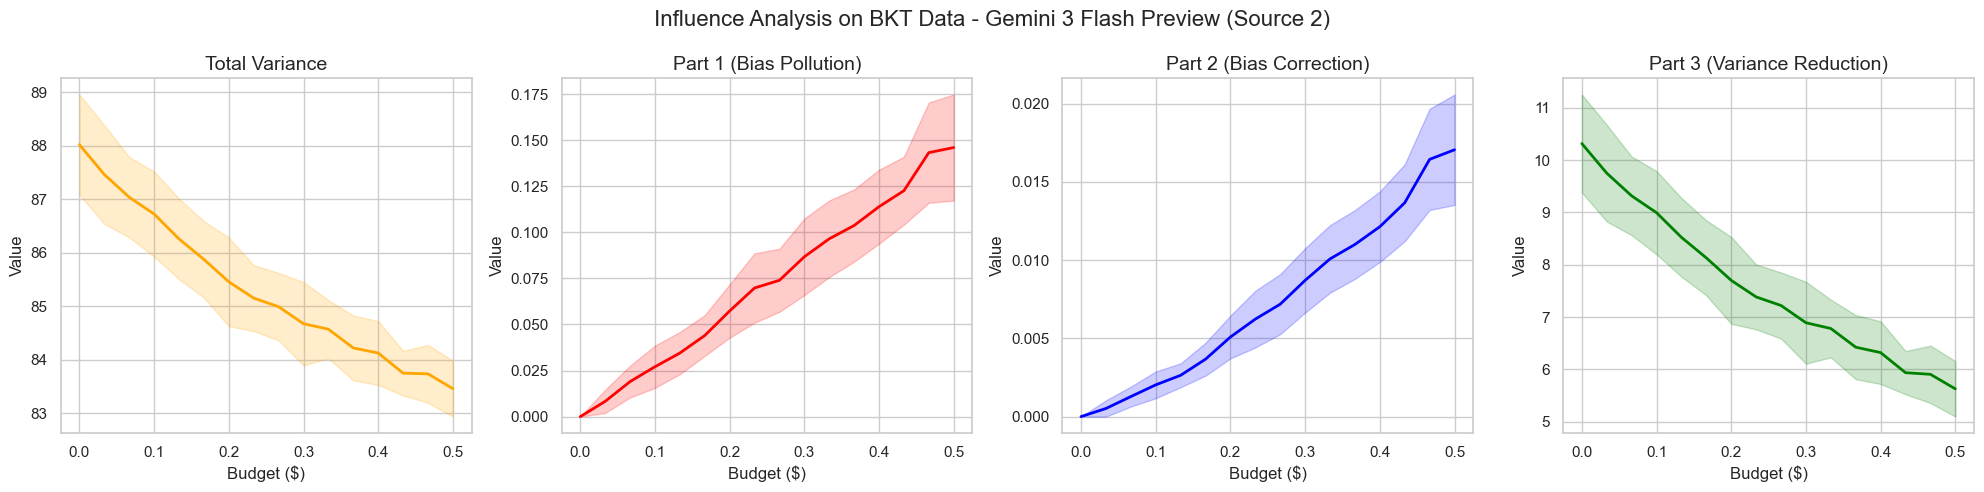

,Num_Annotations,Total_Variance,Part1,Part2,Part3
Budget ($),,,,,
0.000000,0.0,88.016839,0.000000,0.000000,10.314996
0.033333,82.0,87.459434,0.008273,0.000518,9.749836
0.066667,164.0,87.034959,0.018992,0.001279,9.315403
0.100000,246.0,86.720933,0.027050,0.002027,8.994067
0.133333,328.0,86.256498,0.034480,0.002638,8.522813
0.166667,411.0,85.872475,0.043997,0.003668,8.130304
0.200000,493.0,85.454814,0.057309,0.005086,7.700748
0.233333,575.0,85.149892,0.069772,0.006229,7.384505
0.266667,657.0,84.989300,0.073952,0.007183,7.220687


In [20]:
def allocate_budget_bkt_dynamic(n_f, budget, costs, source_idx=None):
    num_s, num_a = n_f.shape
    num_k = len(costs)
    n_alloc = np.zeros((num_k, num_s, num_a), dtype=int)

    patient_list =[]
    rows, cols = n_f.nonzero()
    for s, a in zip(rows, cols):
        count = n_f[s, a]
        patient_list.extend([(s, a)] * count)

    RNG.shuffle(patient_list)

    current_spend = 0.0

    for s, a_factual in patient_list:
        possible_actions = np.arange(num_a)
        possible_counterfactuals = np.delete(possible_actions, a_factual)

        if len(possible_counterfactuals) == 0: continue

        a_target = RNG.choice(possible_counterfactuals)

        if source_idx is not None:
            k = source_idx
        else:
            k = RNG.integers(0, num_k)

        cost = costs[k]

        if current_spend + cost <= budget + 1e-9:
            n_alloc[k, s, a_target] += 1
            current_spend += cost
        else:
            break

    return n_alloc


TEST_SOURCE_IDX = 1 # 0: Gemini-flash-2.5, 1:Claude-hiaku-4.5 2: GPT-4o-mini, 3: GPT-o3-mini
NUM_ROLLS_BKT = 50

max_possible_spend = 1


max_budget_step = min(BUDGET_BKT, max_possible_spend)

budget_steps_bkt = np.linspace(0, max_budget_step, 16)

all_results_bkt =[]

for roll in range(NUM_ROLLS_BKT):
    env = generate_bkt_env(SEED + roll)

    for budget in budget_steps_bkt:
        if budget == 0:
            n_k_alloc = np.zeros_like(env['eps_k'], dtype=int)
        else:
            n_k_alloc = allocate_budget_bkt_dynamic(
                env['n_f'], budget, COSTS_BKT, source_idx=TEST_SOURCE_IDX
            )

        comps = get_variance_components(
            env['n_f'], n_k_alloc,
            env['eps_k'], env['delta_g_k'],
            env['sigma_r_sq'],
            env['pi_e'], env['pi_b'], env['d0'],
            env['term1_const'], env['term2_const']
        )

        res = comps.copy()
        res['Budget ($)'] = budget
        res['Num_Annotations'] = n_k_alloc.sum()
        res['Roll'] = roll
        all_results_bkt.append(res)

df_results_bkt = pd.DataFrame(all_results_bkt)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics =[
    ("Total_Variance", "Total Variance", "orange"),
    ("Part1", "Part 1 (Bias Pollution)", "red"),
    ("Part2", "Part 2 (Bias Correction)", "blue"),
    ("Part3", "Part 3 (Variance Reduction)", "green")
]

llm_names =["Gemini 2.5 Flash", "Gemini 3 Flash Preview", "Claude 3.5 Haiku", "GPT-4o-mini"]
test_llm_name = llm_names[TEST_SOURCE_IDX]

for i, (metric, title, color) in enumerate(metrics):
    sns.lineplot(
        data=df_results_bkt,
        x="Budget ($)",
        y=metric,
        ax=axes[i],
        color=color,
        errorbar='sd',
        linewidth=2
    )
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel("Budget ($)", fontsize=12)
    axes[i].set_ylabel("Value", fontsize=12)

plt.suptitle(f"Influence Analysis on BKT Data - {test_llm_name} (Source {TEST_SOURCE_IDX+1})", fontsize=16)
plt.tight_layout()
plt.show()


df_summary_bkt = df_results_bkt.groupby("Budget ($)").mean().drop(columns=["Roll"])
display(df_summary_bkt[['Num_Annotations', 'Total_Variance', 'Part1', 'Part2', 'Part3']])

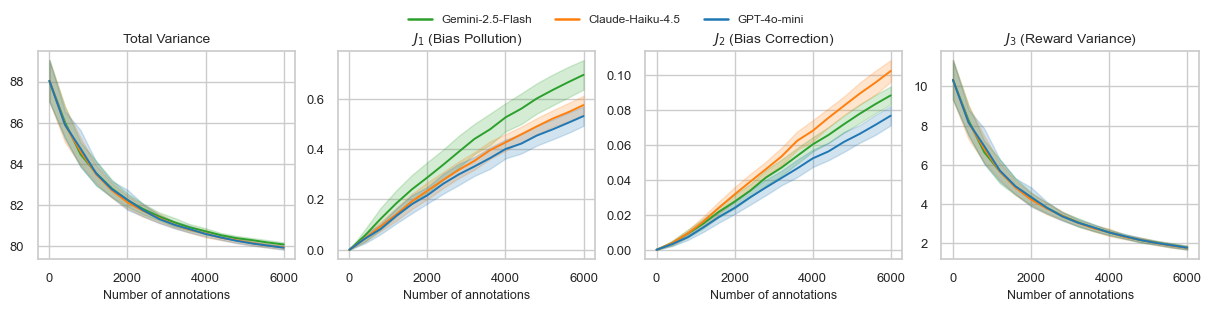

In [21]:
NUM_ROLLS = 100
N_STEPS   = 16

all_results = []
n_steps_grid = np.linspace(0, NUM_PATIENTS_BKT, N_STEPS, dtype=int)

for source_idx in range(NUM_SOURCES_BKT):
    for roll in range(NUM_ROLLS):
        env = generate_bkt_env(SEED + roll)
        for n_target in n_steps_grid:
            budget = n_target * COSTS_BKT[source_idx] * 1.001
            n_k_alloc = allocate_budget_bkt_dynamic(
                env['n_f'], budget, COSTS_BKT, source_idx)
            comps = get_variance_components(
                env['n_f'], n_k_alloc,
                env['eps_k'], env['delta_g_k'], env['sigma_r_sq'],
                env['pi_e'], env['pi_b'], env['d0'],
                env['term1_const'], env['term2_const'])
            comps['Num_Annotations'] = int(n_k_alloc.sum())
            comps['Source'] = source_idx + 1
            comps['Roll']   = roll
            all_results.append(comps)

df_all = pd.DataFrame(all_results)

sns.set_theme(style='whitegrid', font_scale=0.85)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8),
                         sharex=False, constrained_layout=True)

metrics = [
    ("Total_Variance", "Total Variance"),
    ("Part1",          r"$J_1$ (Bias Pollution)"),
    ("Part2",          r"$J_2$ (Bias Correction)"),
    ("Part3",          r"$J_3$ (Reward Variance)"),
]


LLM_info = {
    1: ("Gemini-2.5-Flash",  "tab:green"),
    2: ("Claude-Haiku-4.5",  "tab:orange"),
    3: ("GPT-4o-mini",       "tab:blue"),
}

for i, (metric, title) in enumerate(metrics):
    for k, (lbl, color) in LLM_info.items():
        dfk = df_all[df_all['Source'] == k]
        if dfk.empty:
            continue
        sns.lineplot(
            data=dfk, x='Num_Annotations', y=metric,
            ax=axes[i], color=color, errorbar='sd',
            linewidth=1.4, legend=False)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Number of annotations", fontsize=9)
    axes[i].set_ylabel("")

# Unified legend at the top
handles = [plt.Line2D([0], [0], color=c, lw=1.8)
           for _, c in LLM_info.values()]
labels  = [lbl for lbl, _ in LLM_info.values()]
fig.legend(handles, labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=len(labels), frameon=False, fontsize=8.5)

plt.savefig("LLMs_decomposition.png", bbox_inches='tight', dpi=150)
plt.show()

## Optimization

In [22]:
def calc_objective_bkt(n_k):
    total_n_anno = np.sum(n_k, axis=0)
    N_sa = n_f_bkt + total_n_anno
    valid_mask = (N_sa > 0)

    weighted_bias_sum = np.sum(n_k * eps_k_bkt, axis=0)
    A_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_bias_sum, N_sa, out=A_term, where=valid_mask)

    weighted_delta_sum = np.sum(n_k * delta_g_k_bkt, axis=0)
    N_sq = np.square(N_sa)
    B_term = np.zeros_like(N_sa, dtype=float)
    np.divide(weighted_delta_sum, N_sq, out=B_term, where=valid_mask)

    C_term = np.zeros_like(N_sa, dtype=float)
    np.divide(sigma_r_sq_bkt, N_sa, out=C_term, where=valid_mask)

    part1_sa = w_sa_bkt * np.square(A_term)
    part1_s = np.sum(part1_sa, axis=1)

    part2_inner = np.sum(pi_e_bkt * A_term, axis=1)
    part2_s = np.square(part2_inner)

    coef = w_sa_bkt - np.square(pi_e_bkt)
    part3_sa = coef * (C_term + B_term)
    part3_s = np.sum(part3_sa, axis=1)

    term3_s = part1_s - part2_s + part3_s
    term3_total = np.dot(d0_bkt, term3_s)

    return term1_const_bkt + term2_const_bkt + term3_total

def get_mm_coefficients_bkt(n_k_iter):
    total_n = np.sum(n_k_iter, axis=0)
    N_sa_k = n_f_bkt + total_n
    valid_mask = (N_sa_k > 0)

    weighted_bias = np.sum(n_k_iter * eps_k_bkt, axis=0)
    A_term_k = np.zeros_like(N_sa_k, dtype=float)
    np.divide(weighted_bias, N_sa_k, out=A_term_k, where=valid_mask)

    B_s_k = np.sum(pi_e_bkt * A_term_k, axis=1)

    omega1 = d0_bkt[:, None] * w_sa_bkt
    omega2 = -2 * d0_bkt[:, None] * B_s_k[:, None] * pi_e_bkt
    coef = w_sa_bkt - np.square(pi_e_bkt)
    omega3 = d0_bkt[:, None] * coef

    return omega1, omega2, omega3

# Optimizer
class BudgetOptimizerBKT:
    def __init__(self, n_f, N_s, budget, costs):
        self.n_f = n_f
        self.N_s = N_s
        self.budget = budget
        self.costs = costs
        self.num_sources = len(costs)
        self.num_states, self.num_actions = n_f.shape


        # (K, S, A) to (S, A, K)
        self.eps_val = eps_k_bkt.transpose(1, 2, 0)
        self.delta_val = delta_g_k_bkt.transpose(1, 2, 0)

    def solve_subproblem(self, omega1, omega2, omega3, lam):
        M = np.max(self.N_s)

        H_costs = np.full((self.num_states, self.num_actions, M + 1), np.inf)
        H_vecs = np.zeros((self.num_states, self.num_actions, M + 1, self.num_sources), dtype=int)

        cheapest_k = np.argmin(self.costs)

        # =====================================================================
        # Greedy Pairwise Exchange
        # =====================================================================
        for m in range(M + 1):
            valid_mask = m <= (self.N_s[:, None] - self.n_f)
            if not np.any(valid_mask):
                continue

            N_val = self.n_f + m
            N_val_safe = np.where(N_val == 0, 1, N_val)

            n_vec = np.zeros((self.num_states, self.num_actions, self.num_sources), dtype=int)
            n_vec[:, :, cheapest_k] = m
            n_vec[~valid_mask] = 0

            # A = sum(n_k * eps_k) / N
            A_current = m * self.eps_val[:, :, cheapest_k] / N_val_safe
            A_current[~valid_mask] = 0.0

            improved = True
            while improved:
                best_gain = np.zeros((self.num_states, self.num_actions))
                best_swap_u = np.full((self.num_states, self.num_actions), -1, dtype=int)
                best_swap_v = np.full((self.num_states, self.num_actions), -1, dtype=int)
                best_dA = np.zeros((self.num_states, self.num_actions))

                for u in range(self.num_sources):
                    can_swap_u = (n_vec[:, :, u] > 0) & valid_mask
                    if not np.any(can_swap_u): continue

                    for v in range(self.num_sources):
                        if u == v: continue

                        dA = (self.eps_val[:, :, v] - self.eps_val[:, :, u]) / N_val_safe
                        dB = (self.delta_val[:, :, v] - self.delta_val[:, :, u]) / (N_val_safe**2)
                        dC = self.costs[v] - self.costs[u]

                        gain = -(omega1 * (2 * A_current * dA + dA**2) + omega2 * dA + omega3 * dB + lam * dC)

                        update_mask = can_swap_u & (gain > best_gain + 1e-9)
                        if np.any(update_mask):
                            best_gain[update_mask] = gain[update_mask]
                            best_swap_u[update_mask] = u
                            best_swap_v[update_mask] = v
                            best_dA[update_mask] = dA[update_mask]

                improved_mask = best_gain > 1e-9
                improved = np.any(improved_mask)

                if improved:
                    s_idx, a_idx = np.where(improved_mask)
                    u_to_apply = best_swap_u[improved_mask]
                    v_to_apply = best_swap_v[improved_mask]

                    n_vec[s_idx, a_idx, u_to_apply] -= 1
                    n_vec[s_idx, a_idx, v_to_apply] += 1
                    A_current[improved_mask] += best_dA[improved_mask]

            term_BC = (sigma_r_sq_bkt / N_val_safe) + np.sum(n_vec * self.delta_val, axis=-1) / (N_val_safe**2)
            obj_val = omega1 * (A_current**2) + omega2 * A_current + omega3 * term_BC
            lag_cost = lam * np.sum(n_vec * self.costs, axis=-1)
            current_cost = obj_val + lag_cost
            current_cost[N_val == 0] = np.inf

            H_costs[:, :, m] = np.where(valid_mask, current_cost, np.inf)
            H_vecs[:, :, m, :] = n_vec

        # =====================================================================
        # Step 2: DP
        # =====================================================================
        dp = np.full((self.num_states, M + 1), np.inf)
        dp[:, 0] = 0.0
        parent_m = np.full((self.num_states, self.num_actions, M + 1), -1, dtype=int)

        for a in range(self.num_actions):
            new_dp = np.full((self.num_states, M + 1), np.inf)
            max_m_a = self.N_s - self.n_f[:, a]

            for m in range(M + 1):
                valid_s = m <= max_m_a
                if not np.any(valid_s): continue

                cost_add = H_costs[:, a, m]

                proposed_costs = dp[:, :M + 1 - m] + cost_add[:, None]
                current_costs = new_dp[:, m:]

                update_mask = valid_s[:, None] & (proposed_costs < current_costs)

                new_dp[:, m:][update_mask] = proposed_costs[update_mask]
                parent_m[:, a, m:][update_mask] = m

            dp = new_dp

        for s in range(self.num_states):
            dp[s, self.N_s[s] + 1:] = np.inf

        best_w = np.argmin(dp, axis=1)

        # =====================================================================
        # Step 3: Backtracking
        # =====================================================================
        n_k_new = np.zeros((self.num_sources, self.num_states, self.num_actions), dtype=int)
        curr_w = best_w.copy()

        for a in range(self.num_actions - 1, -1, -1):
            m_chosen = parent_m[np.arange(self.num_states), a, curr_w]
            m_chosen[m_chosen == -1] = 0

            vecs = H_vecs[np.arange(self.num_states), a, m_chosen, :]
            n_k_new[:, :, a] = vecs.T
            curr_w -= m_chosen

        usage = np.sum(n_k_new * self.costs[:, None, None])

        return n_k_new, usage

    def optimize(self, max_mm_iter=10, tol=1e-4):
        n_k = np.zeros_like(eps_k_bkt, dtype=int)
        history =[]

        header = f"{'Iter':<5} | {'Objective':<12} | {'Budget':<10} | {'Total N':<10}"
        for k in range(self.num_sources):
            header += f" | {'N_'+str(k):<8}"
        header += f" | {'Lambda':<10}"

        print(header)
        print("-" * len(header))

        baseline_obj = calc_objective_bkt(n_k)
        row_str_base = f"{'-1':<5} | {baseline_obj:<12.6f} | {'0.0':<10} | {'0':<10}"
        for k in range(self.num_sources):
            row_str_base += f" | {'0':<8}"
        row_str_base += f" | {'N/A':<10}"
        print(row_str_base)

        base_record = {'iter': -1, 'obj': baseline_obj, 'usage': 0.0, 'total_n': 0, 'lambda': np.nan}
        for k in range(self.num_sources): base_record[f'n_{k}'] = 0
        history.append(base_record)

        for k in range(max_mm_iter):
            omega1, omega2, omega3 = get_mm_coefficients_bkt(n_k)

            lam_low = 0.0
            lam_high = 1.0
            while True:
                _, usage = self.solve_subproblem(omega1, omega2, omega3, lam_high)
                if usage <= self.budget: break
                lam_low = lam_high
                lam_high *= 2
                if lam_high > 1e6: break

            best_lam = lam_high
            n_k_next = n_k

            for _ in range(20):
                lam_mid = (lam_low + lam_high) / 2
                n_cand, usage = self.solve_subproblem(omega1, omega2, omega3, lam_mid)
                if usage > self.budget:
                    lam_low = lam_mid
                else:
                    best_lam = lam_mid
                    lam_high = lam_mid
                    n_k_next = n_cand

            n_k_next, final_usage = self.solve_subproblem(omega1, omega2, omega3, best_lam)
            current_obj = calc_objective_bkt(n_k_next)
            total_n = np.sum(n_k_next)

            source_counts = [np.sum(n_k_next[i]) for i in range(self.num_sources)]
            row_str = f"{k:<5} | {current_obj:<12.6f} | {final_usage:<10.1f} | {total_n:<10}"
            for count in source_counts:
                row_str += f" | {count:<8}"
            row_str += f" | {best_lam:<10.4f}"
            print(row_str)

            record = {'iter': k, 'obj': current_obj, 'usage': final_usage, 'total_n': total_n, 'lambda': best_lam}
            for i in range(self.num_sources): record[f'n_{i}'] = source_counts[i]
            history.append(record)

            if k > 0 and np.abs(history[-1]['obj'] - history[-2]['obj']) < tol:
                print("Converged.")
                break
            n_k = n_k_next

        return n_k, pd.DataFrame(history)

# Run Optimization
optimizer_bkt = BudgetOptimizerBKT(n_f_bkt, N_s_bkt, BUDGET_BKT, COSTS_BKT)

print("Starting BKT Education Optimization...")
n_k_opt_bkt, history_df_bkt = optimizer_bkt.optimize(max_mm_iter=15)

print(f"\n Reduction: {(history_df_bkt.iloc[0]['obj'] - history_df_bkt.iloc[-1]['obj'])/history_df_bkt.iloc[0]['obj'] * 100:.2f}%")

Starting BKT Education Optimization...
Iter  | Objective    | Budget     | Total N    | N_0      | N_1      | N_2      | Lambda    
--------------------------------------------------------------------------------------------
-1    | 87.684095    | 0.0        | 0          | 0        | 0        | 0        | N/A       
0     | 79.063899    | 0.5        | 5976       | 2171     | 746      | 3059     | 0.0241    
1     | 79.054818    | 0.5        | 5976       | 2235     | 737      | 3004     | 0.0229    
2     | 79.053203    | 0.5        | 5976       | 2218     | 742      | 3016     | 0.0241    
3     | 79.052685    | 0.5        | 5976       | 2205     | 743      | 3028     | 0.0251    
4     | 79.052520    | 0.5        | 5976       | 2198     | 744      | 3034     | 0.0263    
5     | 79.052484    | 0.5        | 5976       | 2194     | 744      | 3038     | 0.0266    
Converged.

 Reduction: 9.84%


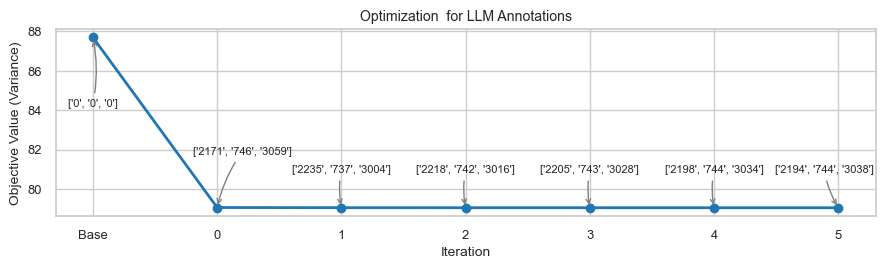

In [41]:
plt.figure(figsize=(9, 2.8))
plot_iters = history_df_bkt['iter'].tolist()
plot_objs = history_df_bkt['obj'].tolist()


plt.plot(plot_iters, plot_objs, marker='o', linestyle='-', color='tab:blue',
         linewidth=2, label='Total Variance', zorder=1)


n_cols = [col for col in history_df_bkt.columns if col.startswith('n_')]


total_points = len(plot_iters)
indices_to_label = [0,1, 2, 3, 4, 5,6]


indices_to_label = sorted(list(set(indices_to_label)))

for idx in indices_to_label:
    it = plot_iters[idx]
    obj = plot_objs[idx]

    n_values = history_df_bkt.iloc[idx][n_cols].tolist()

    n_str_list = [str(int(v)) if v == int(v) else f"{v:.1f}" for v in n_values]

    n_display = f"{n_str_list}"

    if idx == indices_to_label[-1]:
      plt.annotate(n_display,
                 xy=(it, obj),
                 xytext=(-10, 25),
                 textcoords='offset points',
                 ha='center',
                 fontsize=8,
                 arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))
    elif idx == indices_to_label[0]:
        plt.annotate(n_display,
                 xy=(it, obj),
                 xytext=(0, -50),
                 textcoords='offset points',
                 ha='center',
                 fontsize=8,
                 arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))
    elif idx == indices_to_label[1]:
        plt.annotate(n_display,
                 xy=(it, obj),
                 xytext=(18, 38),
                 textcoords='offset points',
                 ha='center',
                 fontsize=8,
                 arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))
    else:
      plt.annotate(n_display,
                  xy=(it, obj),
                  xytext=(0, 25),
                  textcoords='offset points',
                  ha='center',
                  fontsize=8,
                  arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1", color='gray'))


plt.xlabel('Iteration', fontsize=10)
plt.ylabel('Objective Value (Variance)', fontsize=10)
plt.title('Optimization  for LLM Annotations')

plt.xticks(plot_iters, ['Base' if i == -1 else str(i) for i in plot_iters])
plt.grid(True)

plt.tight_layout()
plt.savefig("optimization_llm.png", dpi=300, bbox_inches='tight')
plt.show()